# Imports

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# Real Actual Kernel

## Get data

In [2]:
def mean_std_over_seeds(curves_by_seed):
    """
    curves_by_seed: dict {seed: array of shape (n_train_sizes,)}
    """
    Y = np.stack(list(curves_by_seed.values()), axis=0)
    return Y.mean(axis=0), Y.std(axis=0)


In [3]:
# train_mse[seed] : shape (n_train_sizes, n_lambdas)
# test_mse[seed]  : shape (n_train_sizes, n_lambdas)


In [4]:
def load_best_lambda_curves(pkl_path, best_lambda):
    with open(pkl_path, "rb") as f:
        obj = pickle.load(f)

    train_sizes = obj["train_sizes"]
    lambdas = np.array(obj["lambdas"])
    li = np.where(lambdas == best_lambda)[0][0]

    train_curves = {s: obj["train_mse"][s][:, li] for s in obj["seeds"]}
    test_curves  = {s: obj["test_mse"][s][:, li]  for s in obj["seeds"]}

    train_mean, train_std = mean_std_over_seeds(train_curves)
    test_mean,  test_std  = mean_std_over_seeds(test_curves)

    gap_mean = test_mean - train_mean
    gap_std  = np.sqrt(train_std**2 + test_std**2)

    return {
        "train_sizes": train_sizes,
        "train_mean": train_mean,
        "train_std": train_std,
        "test_mean": test_mean,
        "test_std": test_std,
        "gap_mean": gap_mean,
        "gap_std": gap_std,
    }


In [5]:
def load_best_gaussian_curves(pkl_path, best_sigma_label, best_lambda):
    with open(pkl_path, "rb") as f:
        obj = pickle.load(f)

    train_sizes = obj["train_sizes"]
    lambdas = np.array(obj["lambdas"])
    li = np.where(lambdas == best_lambda)[0][0]

    train_curves = {}
    test_curves  = {}

    for seed in obj["seeds"]:
        entry = obj["results"][seed][best_sigma_label]
        train_curves[seed] = entry["train_mse"][:, li]
        test_curves[seed]  = entry["test_mse"][:, li]

    train_mean, train_std = mean_std_over_seeds(train_curves)
    test_mean,  test_std  = mean_std_over_seeds(test_curves)

    gap_mean = test_mean - train_mean
    gap_std  = np.sqrt(train_std**2 + test_std**2)

    return {
        "train_sizes": train_sizes,
        "train_mean": train_mean,
        "train_std": train_std,
        "test_mean": test_mean,
        "test_std": test_std,
        "gap_mean": gap_mean,
        "gap_std": gap_std,
    }


## All

In [6]:
methods = {
    "Complex kernel (Re)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpart.pkl", 0.03
    ),
    
    "Complex kernel (Mag)": load_best_lambda_curves(
        "results/mse_results_realkernelmagnitude.pkl", 10
    ),
    "Complex kernel (complex)": load_best_lambda_curves(
        "results/mse_results_realkernelcomplexfull.pkl", 0.03
    ),
    "Real kernel": load_best_lambda_curves(
        "results/mse_results_realkernelrealkernel.pkl", 0.03
    ),
    "Real kernel (no norm)": load_best_lambda_curves(
        "results/mse_results_realkernelrealkernelnonorm.pkl", 0.03
    ),
    "Random real": load_best_lambda_curves(
        "results/mse_results_realkernelfakereal.pkl", 10
    ),
    "Random complex": load_best_lambda_curves(
        "results/mse_results_realkernelfakecomplex.pkl", 10
    ),
    "Best Gaussian": load_best_gaussian_curves(
        "results/mse_results_realkernelgaussian.pkl",
        best_sigma_label="grid_2",
        best_lambda=0.001
    ),
    "Complex kernel (Re with no shots)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpartnoshot.pkl", 0.001
    ),
    "Complex kernel (Re with label noise train)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpartlabelnoisetrain.pkl", 0.03
    ),
    "Complex kernel (Re with label noise train and test)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpartlabelnoise.pkl", 0.03
    ),
}



### Test Error(all)

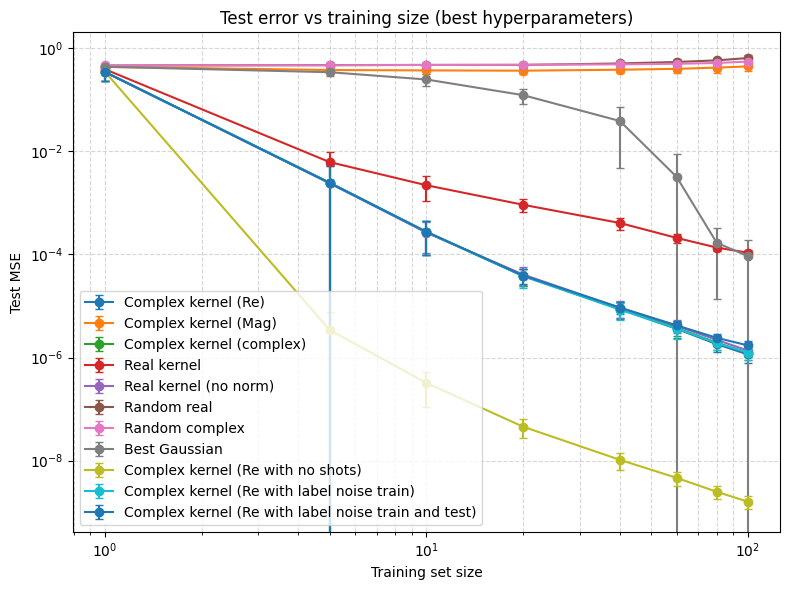

In [7]:
plt.figure(figsize=(8,6))

for name, res in methods.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


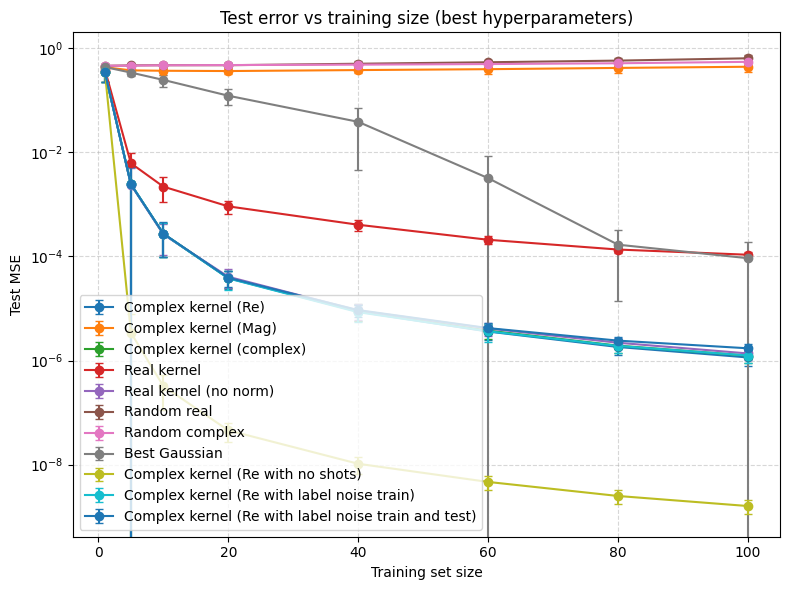

In [8]:
plt.figure(figsize=(8,6))

for name, res in methods.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


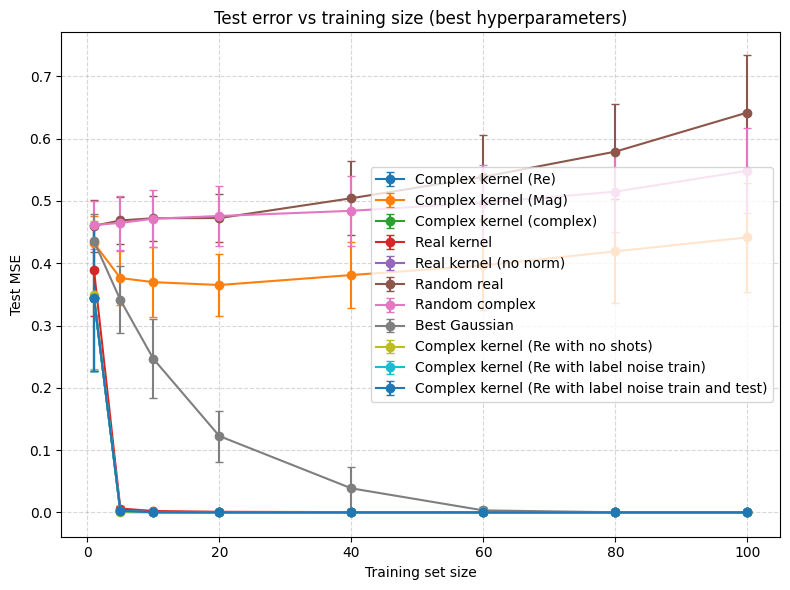

In [9]:
plt.figure(figsize=(8,6))

for name, res in methods.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Train and Test Error

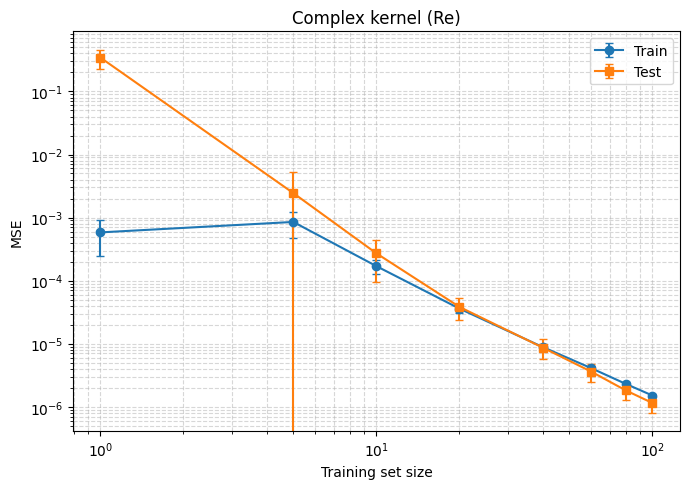

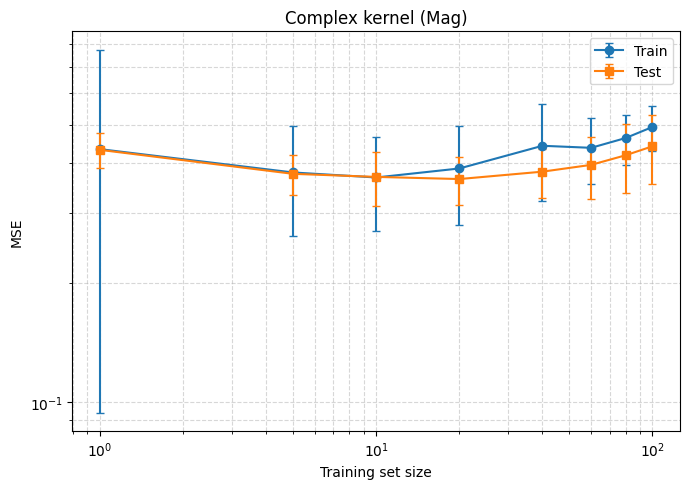

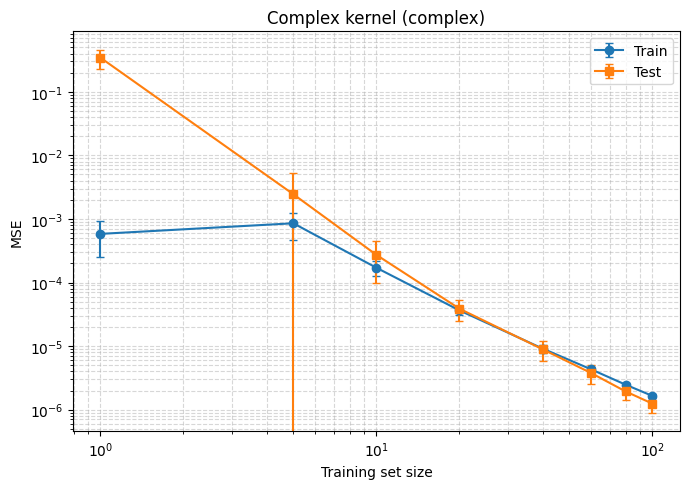

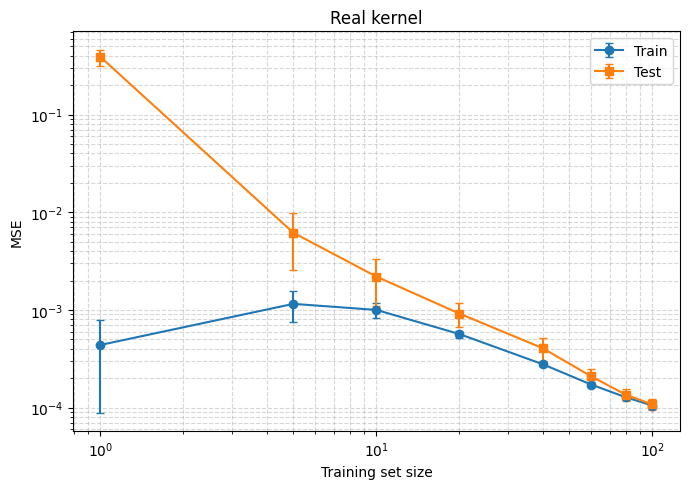

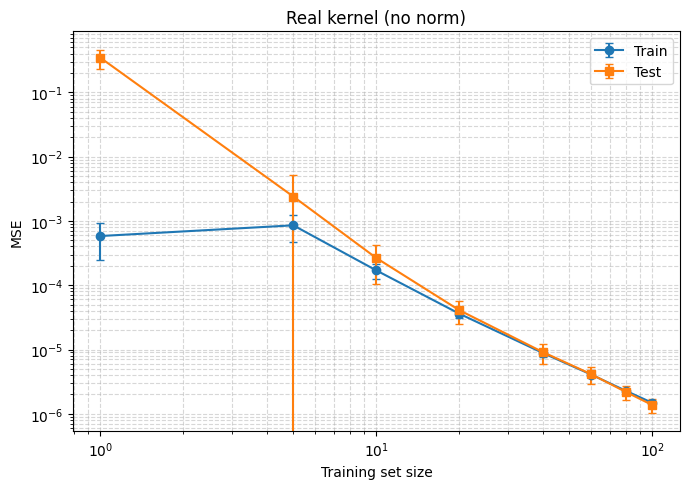

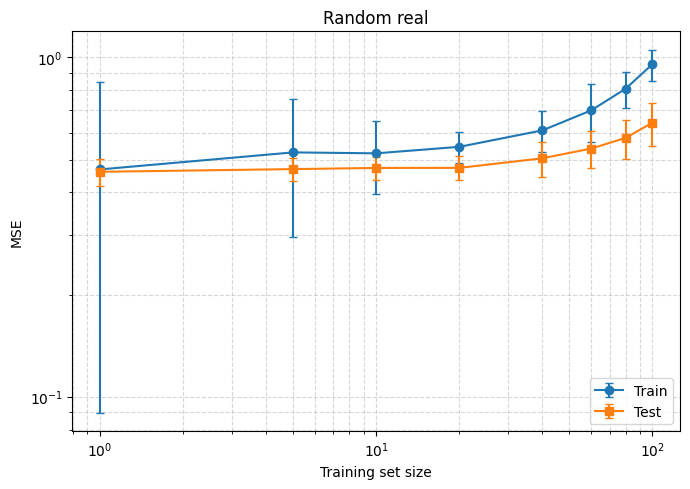

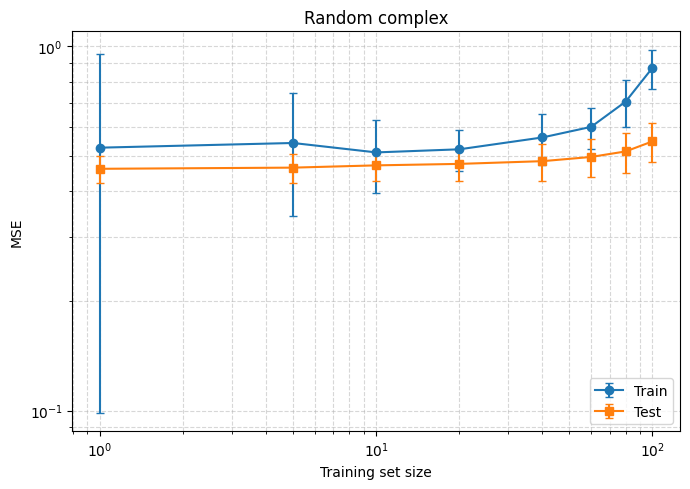

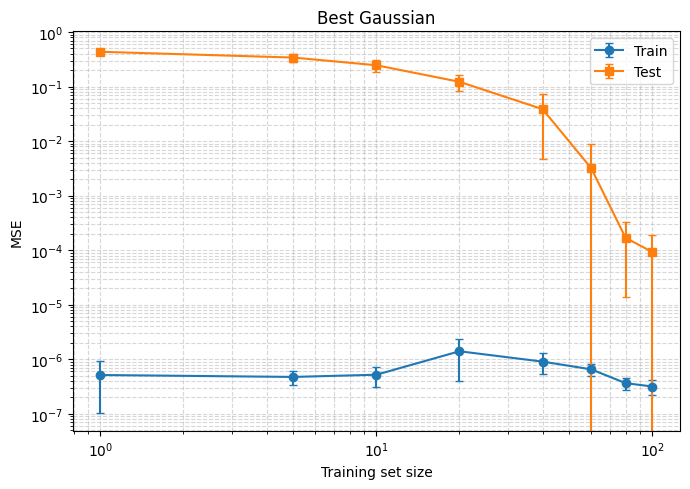

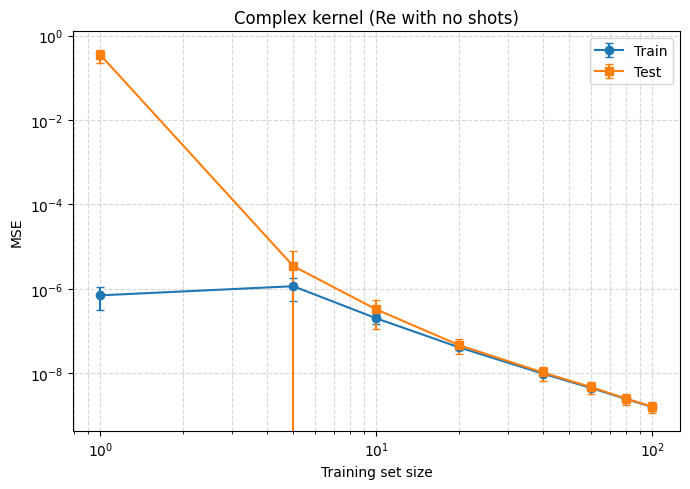

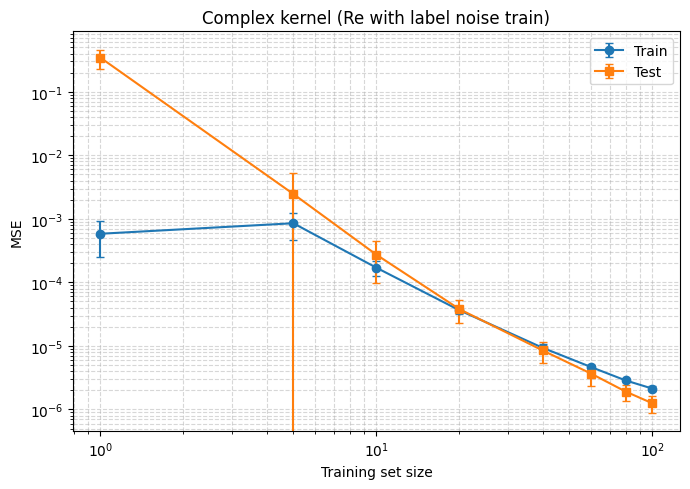

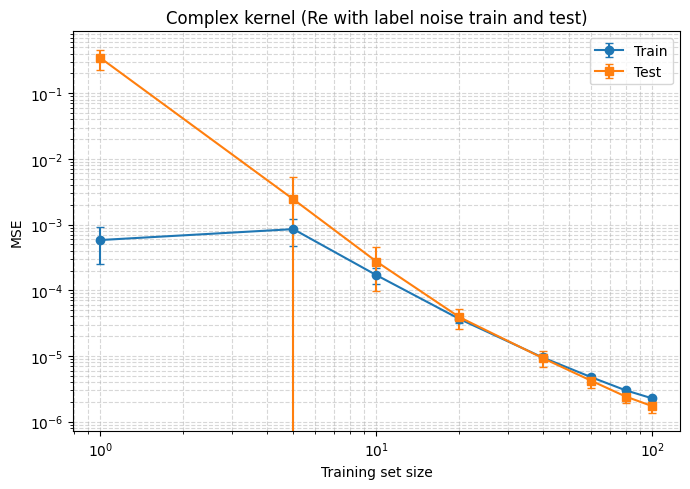

In [10]:
for name, res in methods.items():
    plt.figure(figsize=(7,5))

    plt.errorbar(
        res["train_sizes"],
        res["train_mean"],
        yerr=res["train_std"],
        marker="o",
        capsize=3,
        label="Train"
    )

    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="s",
        capsize=3,
        label="Test"
    )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Training set size")
    plt.ylabel("MSE")
    plt.title(name)
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


### Generalization Gap

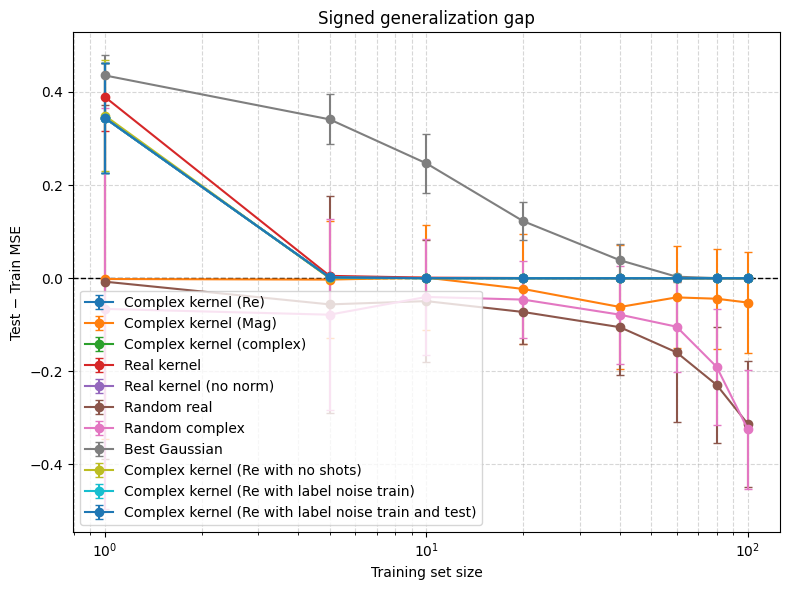

In [11]:
plt.figure(figsize=(8,6))

for name, res in methods.items():
    plt.errorbar(
        res["train_sizes"],
        res["gap_mean"],
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.axhline(0, color="k", lw=1, ls="--")
plt.xscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test − Train MSE")
plt.title("Signed generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


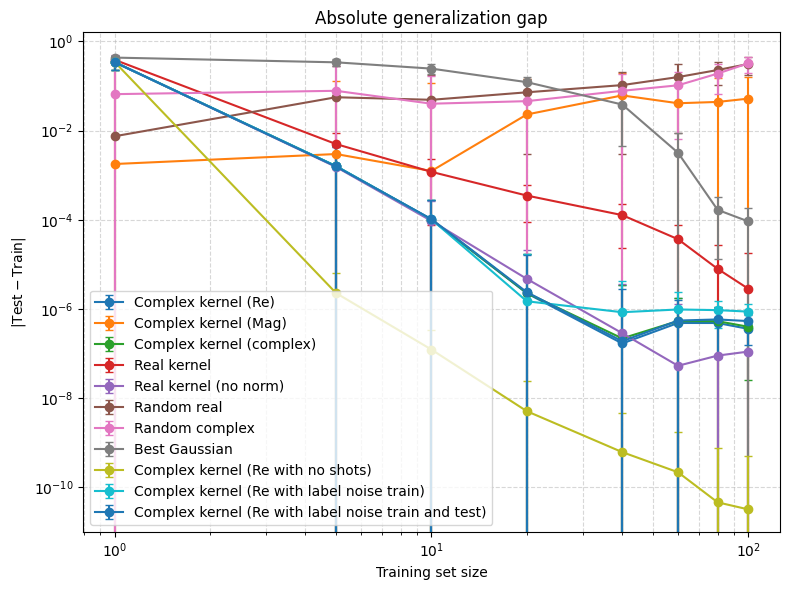

In [12]:
plt.figure(figsize=(8,6))

for name, res in methods.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Best

In [13]:

method_useful = {
    "Complex kernel (Re)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpart.pkl", 0.03
    ),
    "Complex kernel (complex)": load_best_lambda_curves(
        "results/mse_results_realkernelcomplexfull.pkl", 0.03
    ),
    "Real kernel": load_best_lambda_curves(
        "results/mse_results_realkernelrealkernel.pkl", 0.03
    ),
    "Real kernel (no norm)": load_best_lambda_curves(
        "results/mse_results_realkernelrealkernelnonorm.pkl", 0.03
    ),
    "Best Gaussian": load_best_gaussian_curves(
        "results/mse_results_realkernelgaussian.pkl",
        best_sigma_label="grid_2",
        best_lambda=0.001
    ),
    "Complex kernel (Re with no shots)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpartnoshot.pkl", 0.001
    ),
    "Complex kernel (Re with label noise train)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpartlabelnoisetrain.pkl", 0.03
    ),
}

### Test Error

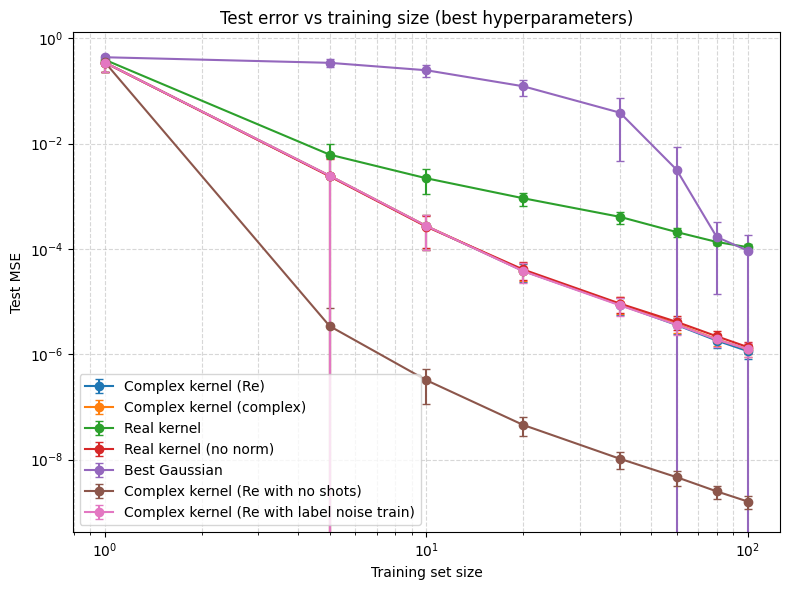

In [14]:
plt.figure(figsize=(8,6))

for name, res in method_useful.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


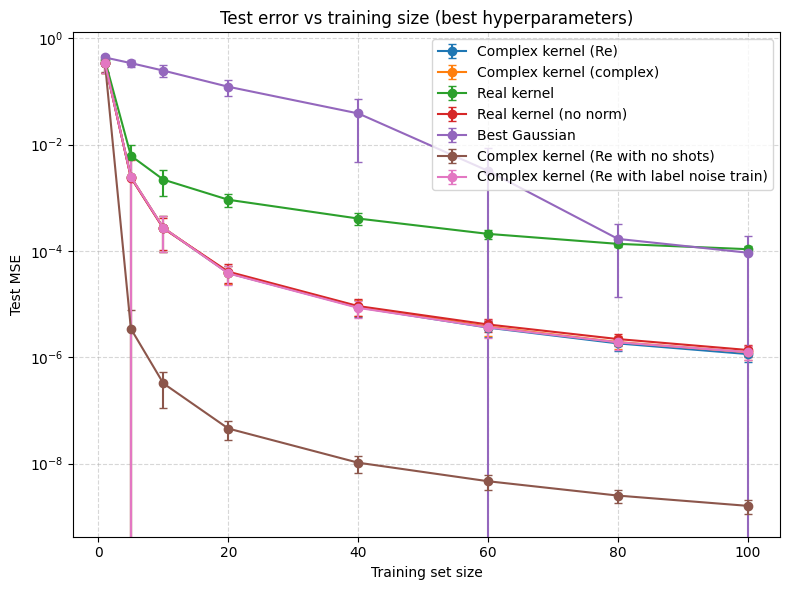

In [15]:
plt.figure(figsize=(8,6))

for name, res in method_useful.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\rjuya\AppData\Local\Temp\ipykernel_28072\1178078787.py:21: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1e-5)


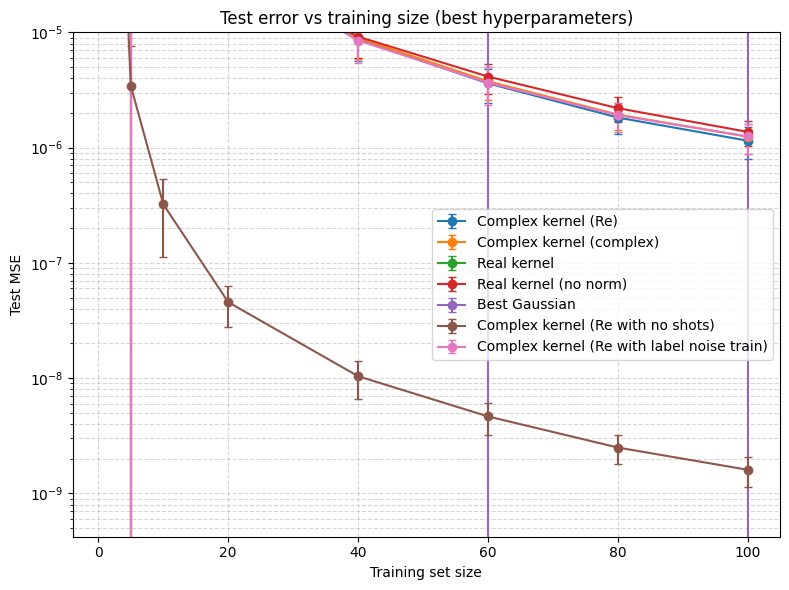

In [16]:
plt.figure(figsize=(8,6))

for name, res in method_useful.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(0,1e-5)
plt.show()


### Generalization Gap

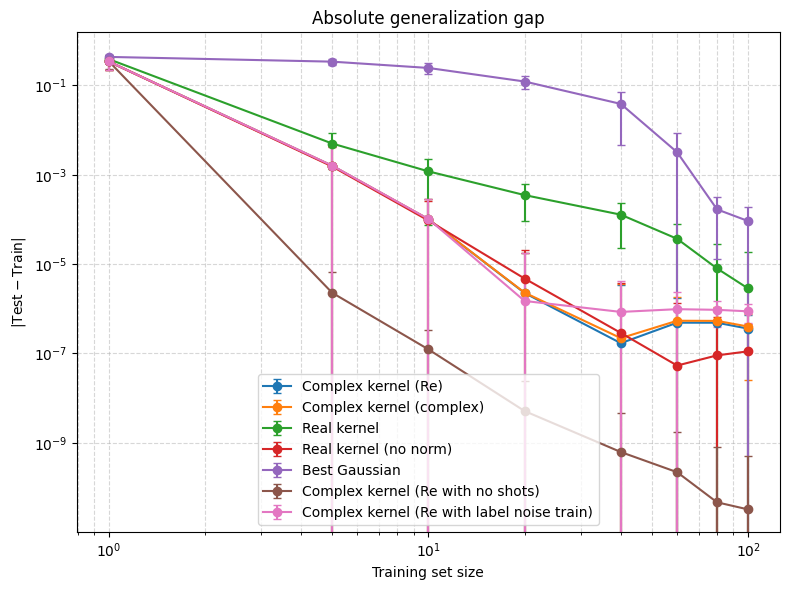

In [17]:
plt.figure(figsize=(8,6))

for name, res in method_useful.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Complex Kernels vs Real Kernel (Quantum)

In [18]:
method_quantum = {
    "Complex kernel (Re)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpart.pkl", 0.03
    ),
    
    "Complex kernel (Mag)": load_best_lambda_curves(
        "results/mse_results_realkernelmagnitude.pkl", 10
    ),
    "Complex kernel (complex)": load_best_lambda_curves(
        "results/mse_results_realkernelcomplexfull.pkl", 0.03
    ),
    "Real kernel": load_best_lambda_curves(
        "results/mse_results_realkernelrealkernel.pkl", 0.03
    ),
    "Real kernel (no norm)": load_best_lambda_curves(
        "results/mse_results_realkernelrealkernelnonorm.pkl", 0.03
    ),
}



### Test Error

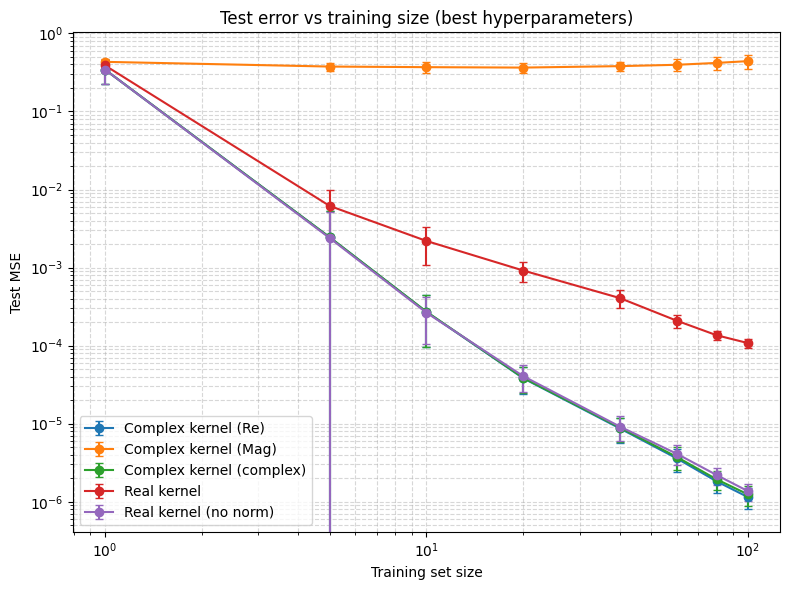

In [19]:
plt.figure(figsize=(8,6))

for name, res in method_quantum.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


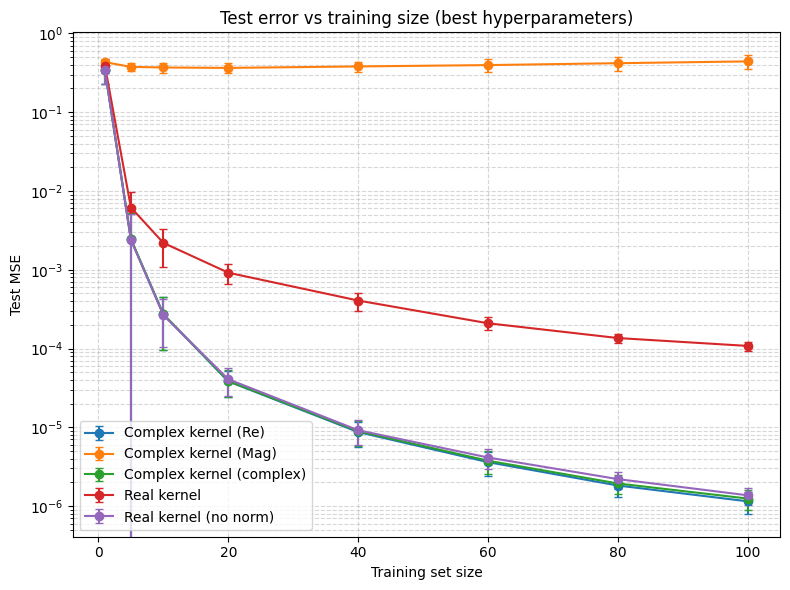

In [20]:
plt.figure(figsize=(8,6))

for name, res in method_quantum.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\rjuya\AppData\Local\Temp\ipykernel_28072\3401854820.py:21: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1e-5)


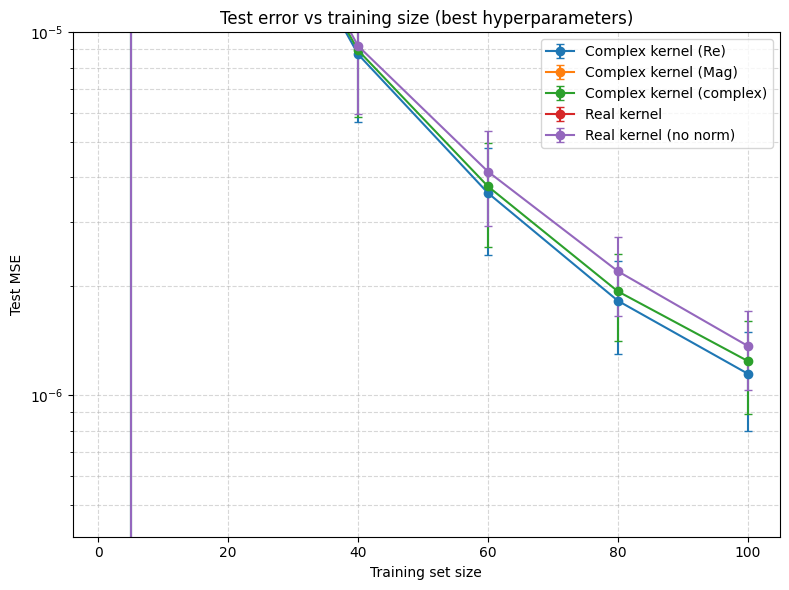

In [21]:
plt.figure(figsize=(8,6))

for name, res in method_quantum.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(0,1e-5)
plt.show()


### Generalization Gap

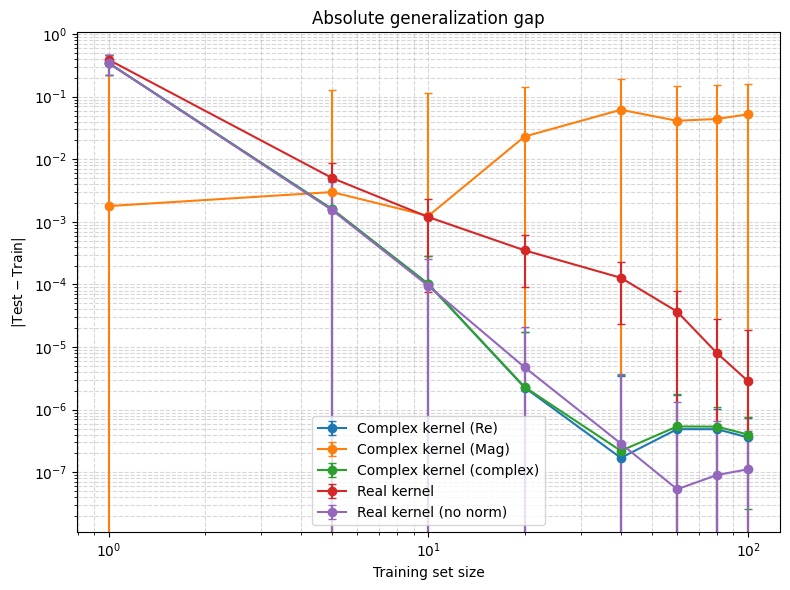

In [22]:
plt.figure(figsize=(8,6))

for name, res in method_quantum.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

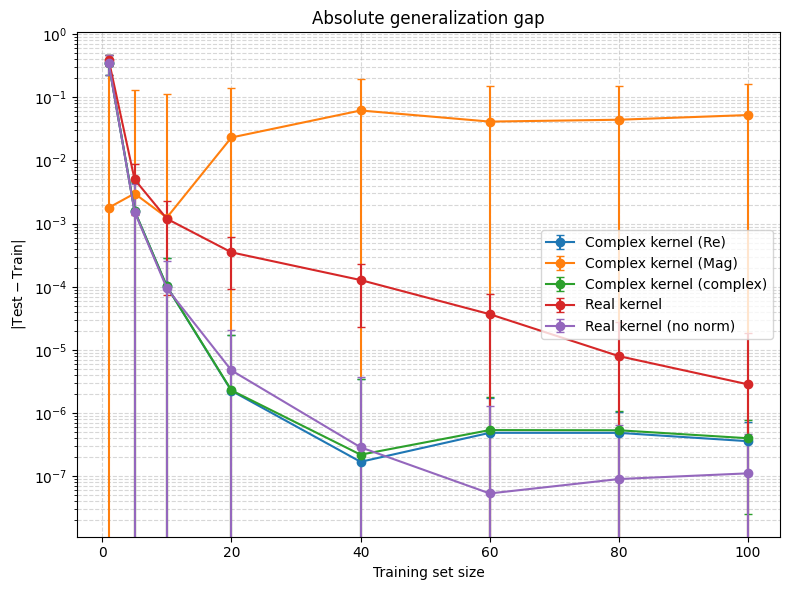

In [23]:
plt.figure(figsize=(8,6))

for name, res in method_quantum.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Quantum vs Random vs Classical

In [24]:
method_qvc = {
    "Complex kernel (Re)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpart.pkl", 0.03
    ),

    "Random real": load_best_lambda_curves(
        "results/mse_results_realkernelfakereal.pkl", 10
    ),
    "Random complex": load_best_lambda_curves(
        "results/mse_results_realkernelfakecomplex.pkl", 10
    ),
    "Best Gaussian": load_best_gaussian_curves(
        "results/mse_results_realkernelgaussian.pkl",
        best_sigma_label="grid_2",
        best_lambda=0.001
    ),
}



### Test Error

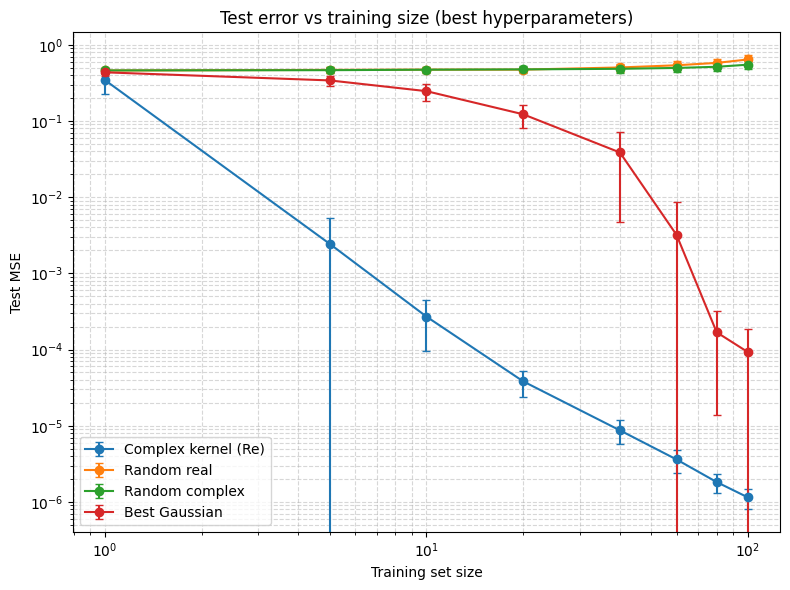

In [25]:
plt.figure(figsize=(8,6))

for name, res in method_qvc.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


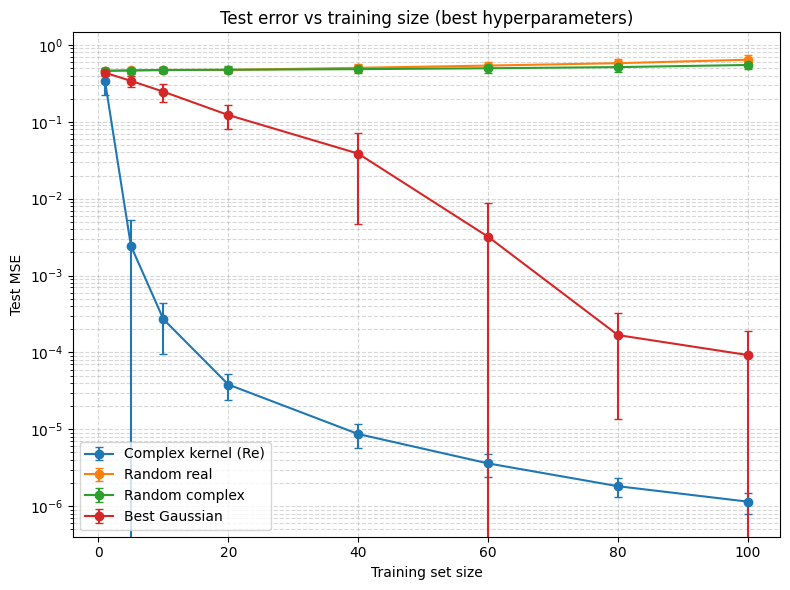

In [26]:
plt.figure(figsize=(8,6))

for name, res in method_qvc.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\rjuya\AppData\Local\Temp\ipykernel_28072\1066401948.py:21: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1e-5)


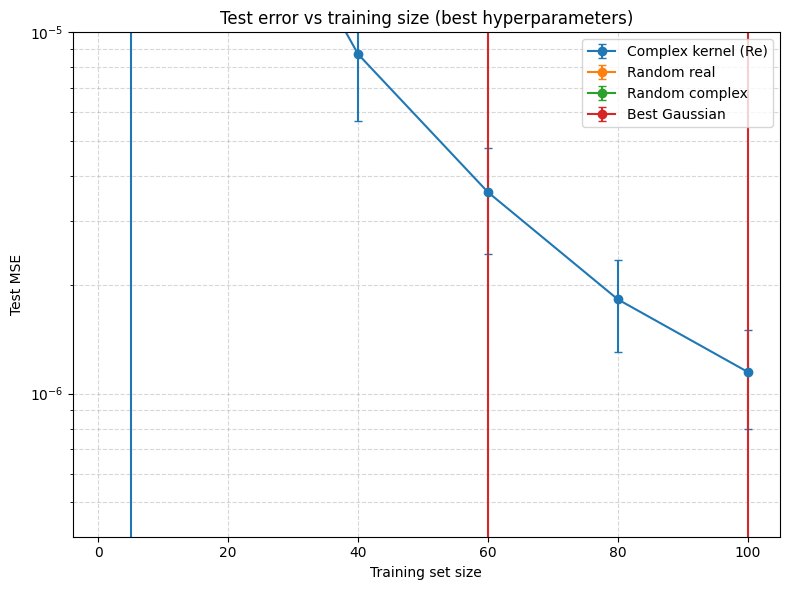

In [27]:
plt.figure(figsize=(8,6))

for name, res in method_qvc.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(0,1e-5)
plt.show()


### Generalization Gap

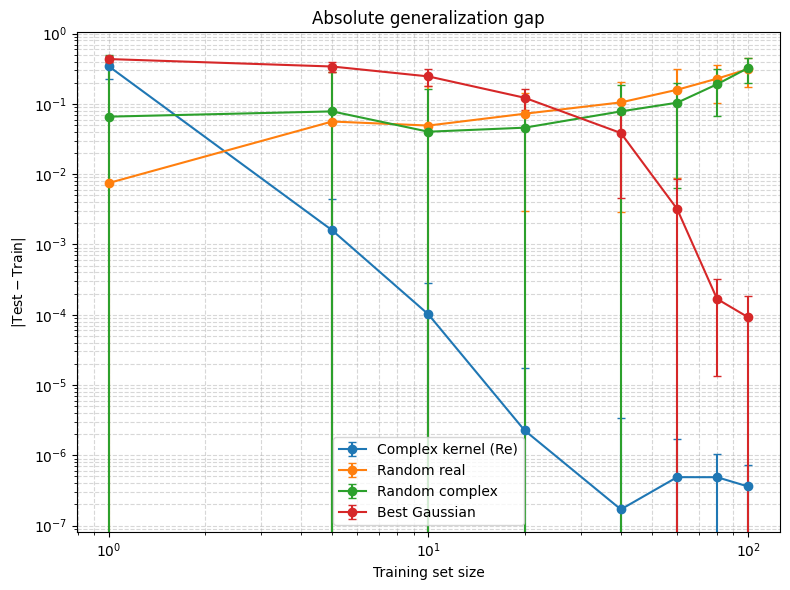

In [28]:
plt.figure(figsize=(8,6))

for name, res in method_qvc.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

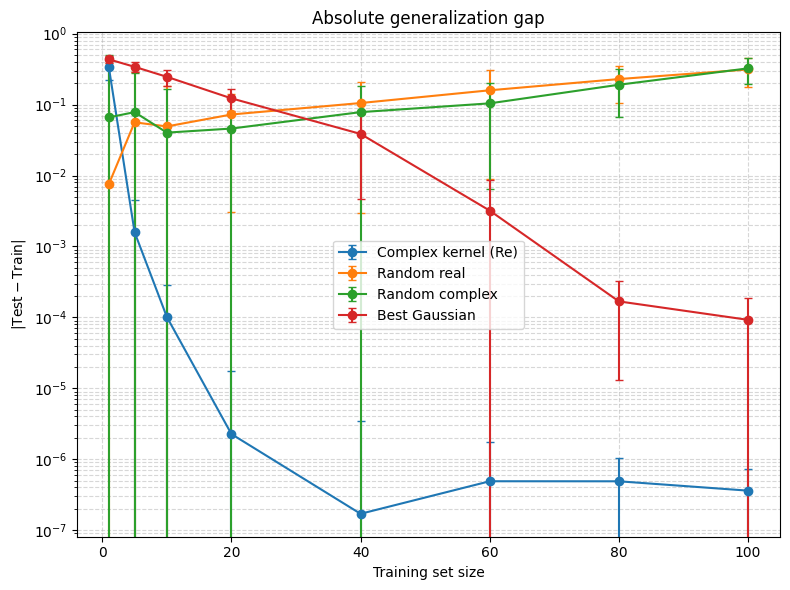

In [29]:
plt.figure(figsize=(8,6))

for name, res in method_qvc.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Quantum Kernel vs Noise

In [30]:
method_noise = {
    "Complex kernel (Re)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpart.pkl", 0.03
    ),
    
    "Complex kernel (Re with no shots)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpartnoshot.pkl", 0.001
    ),
    "Complex kernel (Re with label noise train)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpartlabelnoisetrain.pkl", 0.03
    ),
    "Complex kernel (Re with label noise train and test)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpartlabelnoise.pkl", 0.03
    ),
}



### Test Error

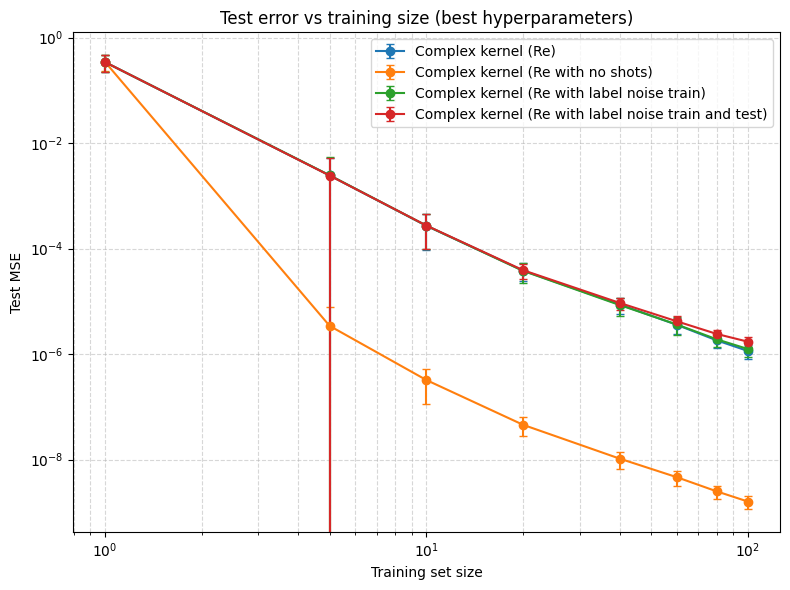

In [31]:
plt.figure(figsize=(8,6))

for name, res in method_noise.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


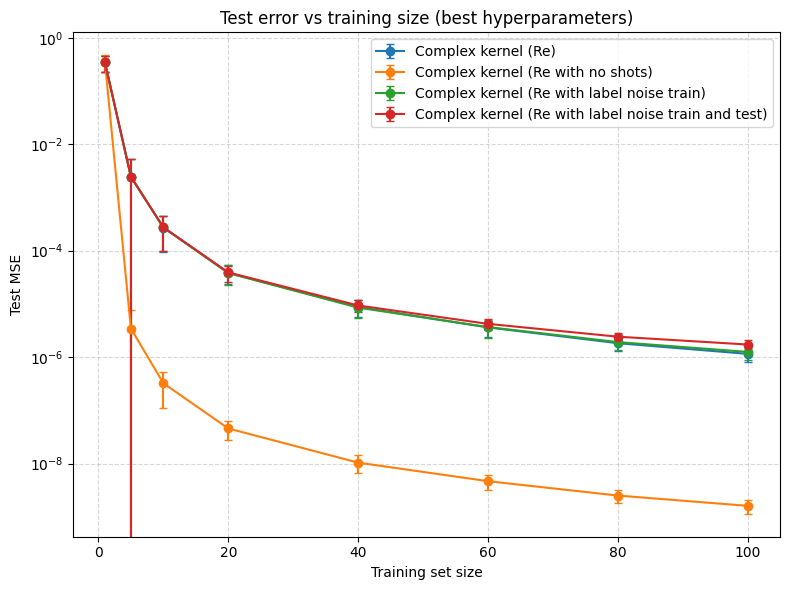

In [32]:
plt.figure(figsize=(8,6))

for name, res in method_noise.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\rjuya\AppData\Local\Temp\ipykernel_28072\2874175259.py:21: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1e-5)


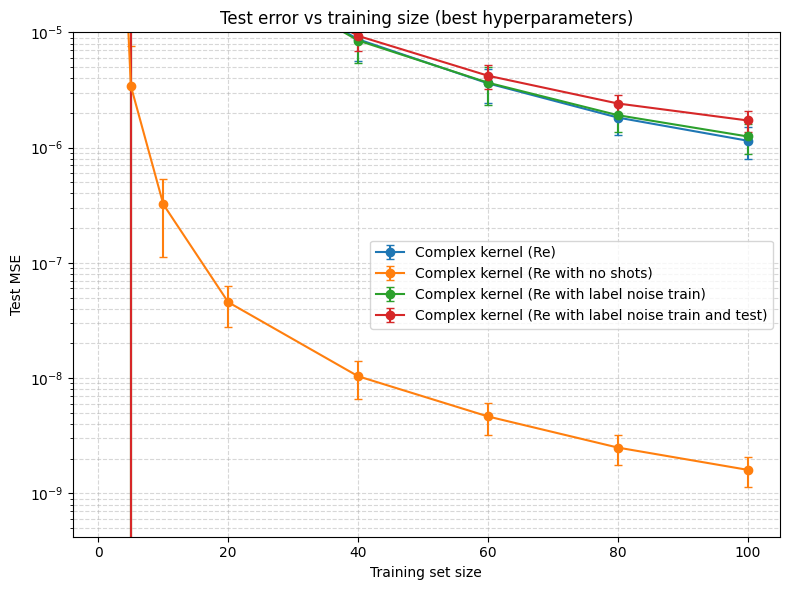

In [33]:
plt.figure(figsize=(8,6))

for name, res in method_noise.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(0,1e-5)
plt.show()


### Generalization Gap

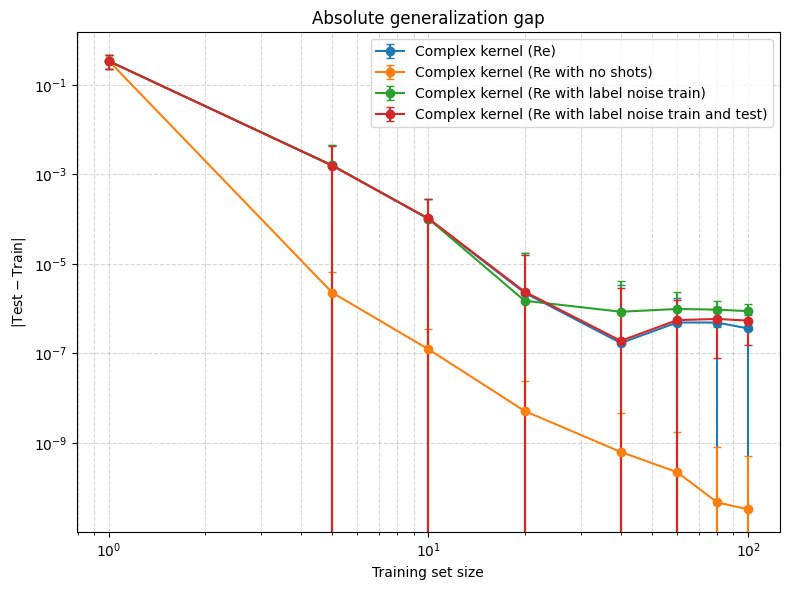

In [34]:
plt.figure(figsize=(8,6))

for name, res in method_noise.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

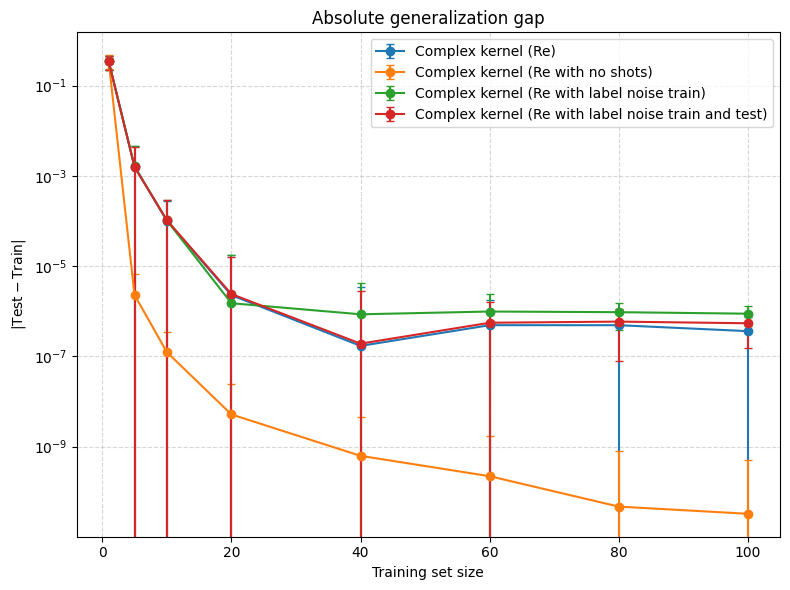

In [35]:
plt.figure(figsize=(8,6))

for name, res in method_noise.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Out of Distribution for Quantum Kernel

In [36]:

method_ood = {
    "Complex kernel (Re)(-2pi to 2pi)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpart.pkl", 0.03
    ),
    "Complex kernel (Re)(-pi/2 to pi/2)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpartmpi2pi2.pkl", 0.03
    ),
    "Complex kernel (Re)(0 to pi)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpart0pi.pkl", 0.03
    ),
    "Complex kernel (Re)(0 to pi/2)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpart0pi2.pkl", 0.03
    ),
    "Complex kernel (Re)(-pi/4 to pi/4)": load_best_lambda_curves(
        "results/mse_results_realkernelrealpartmpi4pi4.pkl", 0.03
    ),
   
}

### Test Error

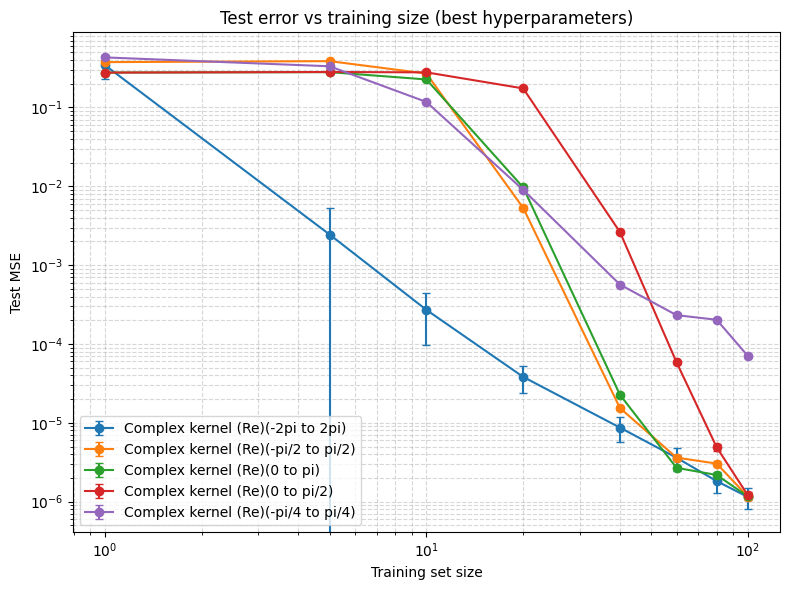

In [37]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [38]:
for name, res in method_ood.items():
    print(res["test_std"])

[1.17982414e-01 2.86144133e-03 1.74795936e-04 1.42832760e-05
 3.02420038e-06 1.17920375e-06 5.22696923e-07 3.49848679e-07]
[2.07584136e-04 1.50240902e-04 2.96003010e-03 3.25408187e-04
 9.55239947e-07 2.60632798e-07 2.15262997e-07 1.17812980e-07]
[1.42083330e-04 6.83885740e-05 5.39228658e-04 3.84066448e-04
 1.40776325e-06 1.30978309e-07 1.00749206e-07 4.00470555e-08]
[1.42083330e-04 5.28583447e-05 8.38294410e-05 1.28488943e-03
 1.07513352e-04 2.72722347e-06 4.56827935e-07 1.06820546e-07]
[2.45985888e-05 1.22078923e-03 2.66432914e-03 3.71798348e-04
 1.87566560e-05 1.22106122e-05 1.25792255e-05 4.85021099e-06]


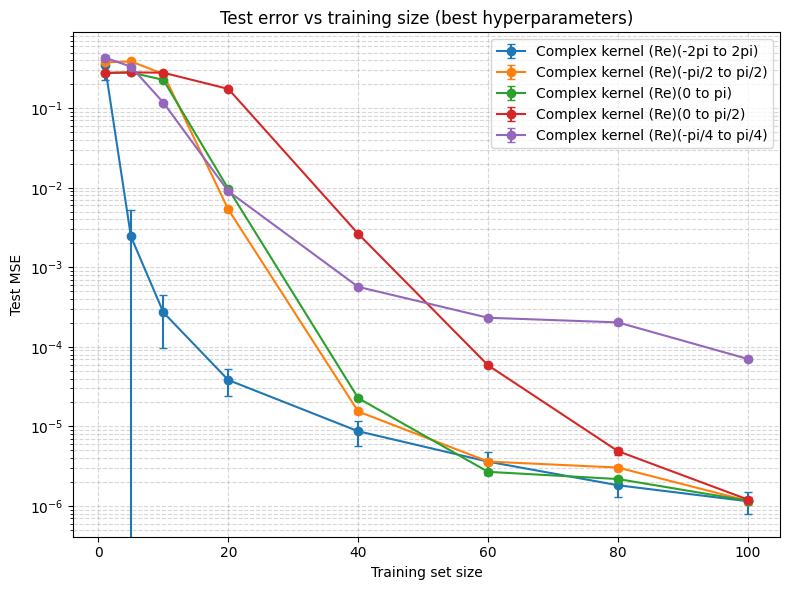

In [39]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


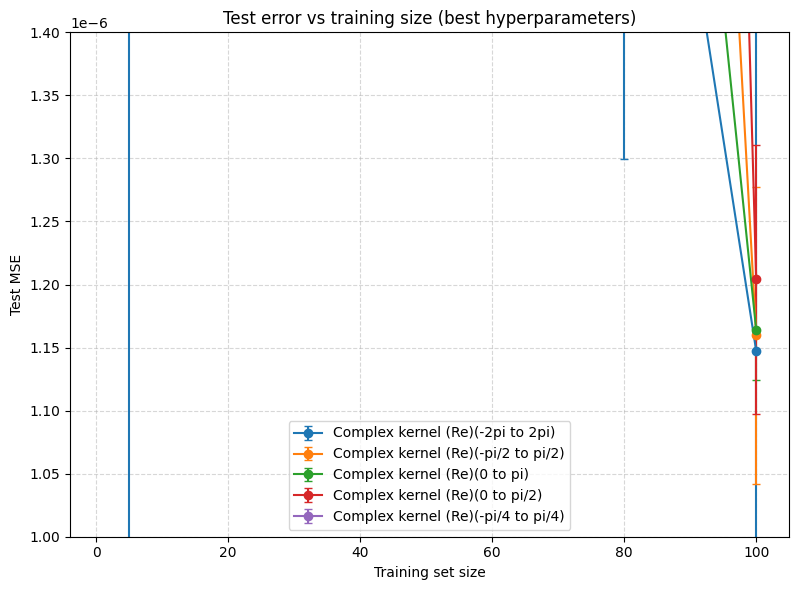

In [40]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.ylim(1e-6,1.4e-6)
plt.show()


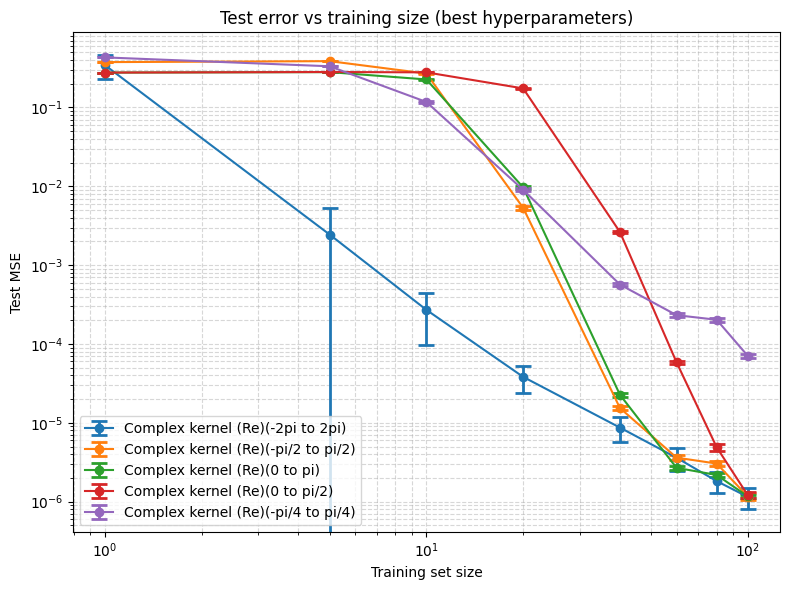

In [41]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        res["test_mean"],
        yerr=res["test_std"],
        marker="o",
        capsize=6,
        elinewidth=2,
        capthick=2,
        label=name
    )


plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Test error vs training size (best hyperparameters)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


### Generalization Gap

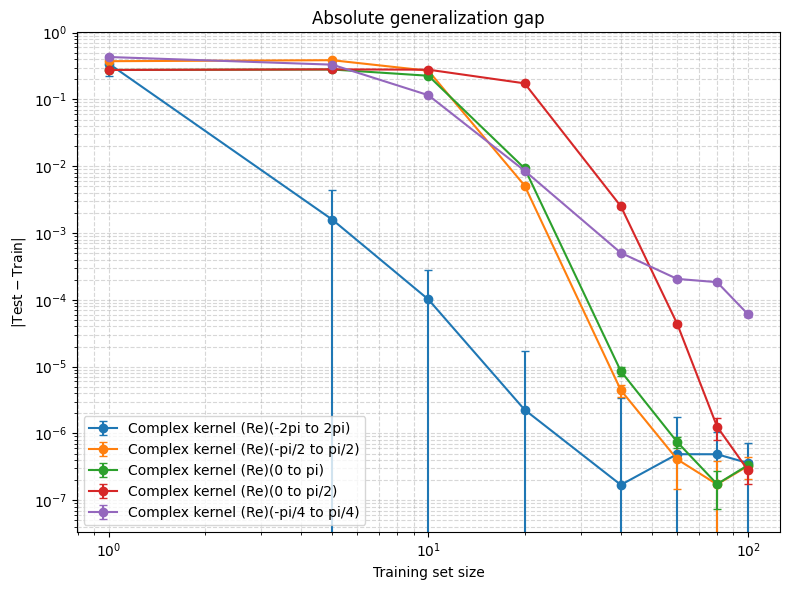

In [42]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

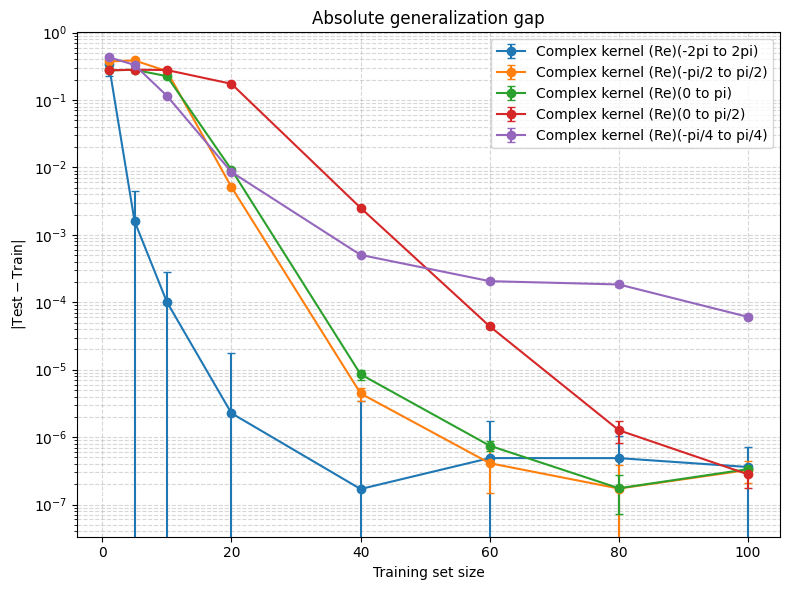

In [43]:
plt.figure(figsize=(8,6))

for name, res in method_ood.items():
    plt.errorbar(
        res["train_sizes"],
        np.abs(res["gap_mean"]),
        yerr=res["gap_std"],
        marker="o",
        capsize=3,
        label=name
    )

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Training set size")
plt.ylabel(r"$|\mathrm{Test - Train}|$")
plt.title("Absolute generalization gap")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()